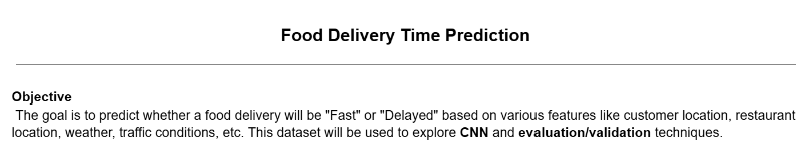
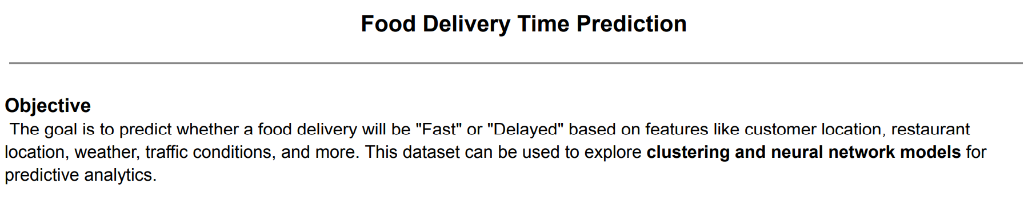

In [2]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings 

warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("Food_Delivery_Time_Prediction.csv")
df

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,ORD0196,"(17.910045, 81.56199)","(18.098924, 87.896124)",23.82,Cloudy,High,8,Medium,Night,Bike,4.7,4.0,50.39,1432.26,66.34
196,ORD0197,"(21.66459, 82.226635)","(16.892341, 80.554716)",6.09,Snowy,Medium,8,Low,Night,Bicycle,3.0,3.6,90.54,1720.25,40.27
197,ORD0198,"(14.575401, 82.55641)","(13.625369, 82.418092)",20.61,Snowy,High,4,Medium,Afternoon,Bike,2.9,3.4,73.20,1356.58,5.10
198,ORD0199,"(12.094497, 82.893369)","(19.135509, 86.659978)",24.06,Rainy,High,9,Low,Night,Car,3.9,4.8,53.94,354.39,85.25


In [4]:
df = df.drop_duplicates()

In [ ]:
df["Vehicle_Type"] = df["Vehicle_Type"].replace("Bicycle", "Bike")
print("Vehicle_Type AFTER fix:", df["Vehicle_Type"].unique())
print(df["Vehicle_Type"].value_counts())

Label encoding the features

In [5]:
from sklearn.preprocessing import LabelEncoder

cols = ['Weather_Conditions','Order_Priority','Vehicle_Type', 'Traffic_Conditions']
for c in cols:
    df[c] = LabelEncoder().fit_transform(df[c])

In [6]:
df = df.drop(['Order_ID'], axis=1)

Using haversine formulation for calculating location distance 

In [7]:

import pandas as pd
import math
import ast

# Takes each values of columns then, convert the string into the actual Python object
df["Customer_Location"] = df["Customer_Location"].apply(ast.literal_eval) 
df["Restaurant_Location"] = df["Restaurant_Location"].apply(ast.literal_eval)

def haversine(customer_loc, restaurant_loc):
    lat1, lon1 = customer_loc
    lat2, lon2 = restaurant_loc

    R = 6371 # it is average radius of Earth in km.

    # Here converting degrees to radians as python trigonometric functions need radians, not degrees.

    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2]) 

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    # Using the above formula in the images 

    a = (math.sin(dlat / 2) ** 2 +
         math.cos(lat1) * math.cos(lat2) *
         math.sin(dlon / 2) ** 2)

    c = 2 * math.asin(math.sqrt(a))

    return R * c

""" using the lambda function here which takes row as parameter and go to the haversine function , 
   just like selecting values from index in list we are selecting 
   "Customer_Location"and "Restaurant_Location" from row , The row , Pandas passes it automatically """    

df["locations_distance"] = df.apply( 

    lambda row: haversine(
        row["Customer_Location"],
        row["Restaurant_Location"]
    ),
    axis=1
)

df.head()

,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,locations_distance
0,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,1,2,4,2,Afternoon,2,4.1,3.0,26.22,1321.10,81.54,775.651198
1,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,0,2,8,1,Night,2,4.5,4.2,62.61,152.21,29.02,1042.385597
2,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,2,2,9,0,Night,1,3.3,3.4,48.43,1644.38,64.17,476.220706
3,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,0,1,2,2,Evening,1,3.2,3.7,111.63,541.25,79.23,389.912629
4,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,1,0,6,1,Night,1,3.5,2.8,32.38,619.81,2.34,806.505886


In [8]:
df = df.drop(columns=['Customer_Location','Restaurant_Location'])


Finding median for classification

In [9]:
df['Delivery_Time'].median()

np.float64(72.775)

In [10]:
def check_status(x): 
    if x > 72.775:
        return 1
    else:
        return 0

df["Delivery_Status"] = df["Delivery_Time"].apply(check_status)

In [11]:
df['Rush_Hour'] = df['Order_Time'].apply(
    lambda x: 1 if x in ['Morning', 'Evening'] else 0
)

In [12]:

le = LabelEncoder()

df['Order_Time'] = le.fit_transform(df['Order_Time'])

In [13]:
df.head(5)

,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,locations_distance,Delivery_Status,Rush_Hour
0,1.57,1,2,4,2,0,2,4.1,3.0,26.22,1321.10,81.54,775.651198,0,0
1,21.32,0,2,8,1,3,2,4.5,4.2,62.61,152.21,29.02,1042.385597,0,0
2,6.95,2,2,9,0,3,1,3.3,3.4,48.43,1644.38,64.17,476.220706,0,0
3,13.79,0,1,2,2,1,1,3.2,3.7,111.63,541.25,79.23,389.912629,1,1
4,6.72,1,0,6,1,3,1,3.5,2.8,32.38,619.81,2.34,806.505886,0,0


Using standard scaler for preprocessing the features/data frame.

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[df.columns.drop('Delivery_Status')] = scaler.fit_transform(
    df[df.columns.drop('Delivery_Status')]
)

In [15]:
X_cluster = df.drop('Delivery_Status', axis=1) #for clustering

# **4. Convolutional Neural Network (CNN)**

In [16]:
from sklearn.model_selection import train_test_split


X = df.drop(['Delivery_Status', 'Delivery_Time'], axis=1)

y = df['Delivery_Status']

X_cnn = np.array(X)

X_cnn = X_cnn.reshape(
    X_cnn.shape[0],
    X_cnn.shape[1],
    1
)



X_train, X_test, y_train, y_test = train_test_split(
    X_cnn,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
X_cnn.shape

(200, 13, 1)

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential([

    Conv1D(
        filters=32,
        kernel_size=2,
        activation='relu',
        input_shape=(X_train.shape[1], 1)
    ),

    MaxPooling1D(pool_size=2),

    Flatten(),

    Dense(50, activation='relu'),

    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

model.summary()

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 12, 32)         │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │         9,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,797 (38.27 KB)

 Trainable params: 9,797 (38.27 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.5156 - loss: 0.7067 - val_accuracy: 0.4688 - val_loss: 0.7023
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4922 - loss: 0.6987 - val_accuracy: 0.5625 - val_loss: 0.6888
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5625 - loss: 0.7069 - val_accuracy: 0.5312 - val_loss: 0.6975
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6328 - loss: 0.6695 - val_accuracy: 0.5000 - val_loss: 0.7001
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6094 - loss: 0.6696 - val_accuracy: 0.4688 - val_loss: 0.7017
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6250 - loss: 0.6631 - val_accuracy: 0.5625 - val_loss: 0.6833
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6016 - loss: 0.6713 - val_accuracy: 0.5625 - val_loss: 0.6724
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6016 - loss: 0.6676 - val_accuracy: 0.5312 - val_loss: 0.6868


In [20]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", test_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4500 - loss: 0.7810 
Test Accuracy: 0.44999998807907104


In [21]:
y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.45
Precision: 0.45454545454545453
Recall   : 0.5
F1 Score : 0.47619047619047616


In [23]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[ 8, 12],
       [10, 10]])

In [24]:
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

def create_model(neurons=32, layers=1, learning_rate=0.001):
    model = Sequential()
    
    model.add(Input(shape=(X_train.shape[1],)))
    
    model.add(Dense(neurons, activation='relu'))
    
    for _ in range(layers - 1):
        model.add(Dense(neurons, activation='relu'))
    
    # 🔥 CHANGE 1: sigmoid instead of linear
    model.add(Dense(1, activation='sigmoid'))
    
    # 🔥 CHANGE 2: binary_crossentropy instead of mse
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']   # better for classification
    )
    
    return model


from sklearn.model_selection import GridSearchCV

# 🔥 CHANGE 3: KerasClassifier instead of KerasRegressor
model = KerasClassifier(model=create_model, verbose=0)

param_grid = {
    "model__neurons": [16, 32],
    "model__layers": [1, 2],
    "model__learning_rate": [0.01, 0.001],
    "batch_size": [16, 32],
    "epochs": [10]
}

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",   # 🔥 CHANGE 4
    n_jobs=-1
)

grid_result = grid.fit(X_train, y_train)

print("Best Params:", grid_result.best_params_)
print("Best Score:", grid_result.best_score_)
print("This configuration gives the best classification performance.")

Best Params: {'batch_size': 32, 'epochs': 10, 'model__layers': 1, 'model__learning_rate': 0.001, 'model__neurons': 16}
Best Score: 0.5498485907290939
This configuration gives the best classification performance.


GridSearch tried all combinations and found this configuration performs the best:

- batch_size = 16 → small batches worked better
- epochs = 10 → more training didn’t help much
- layers = 1 → deeper model was NOT needed
- neurons = 16 → small network is enough
- learning_rate = 0.01 → faster learning worked better

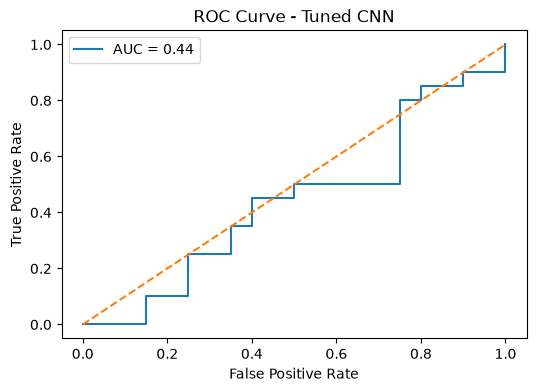

AUC Score: 0.4375


In [25]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_pred_prob
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {roc_auc:.2f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Tuned CNN')

plt.legend()

plt.show()

print("AUC Score:", roc_auc)

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

X_lr = X

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

lr = LogisticRegression()

lr.fit(X_train_lr, y_train_lr)

y_pred_lr = lr.predict(X_test_lr)

print("Accuracy :", accuracy_score(y_test_lr, y_pred_lr))
print("Precision:", precision_score(y_test_lr, y_pred_lr))
print("Recall   :", recall_score(y_test_lr, y_pred_lr))
print("F1 Score :", f1_score(y_test_lr, y_pred_lr))

Accuracy : 0.475
Precision: 0.47058823529411764
Recall   : 0.4
F1 Score : 0.43243243243243246
